# AISIT Hackathon Competition Reference Notebook

The contents of this notebook are based on https://github.com/NOC-MDP/AISIT/tree/main and adapted to the competition template. 
This notebook should edited with your code, text and graphics for [INSERT YEAR HERE] AISIT Hackathon Competition.  

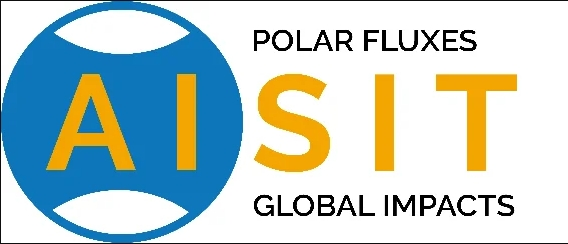

## Challenge 

We want you to develop a Python notebook which harnesses our database to produce a gridded dataset 18O isotope abundance across the Arctic ocean.  

Your notebooks should be entirely self-contained (i.e. we have everything we need to run them from your submission folder using a clean Python 3.9 environment with access to pip). 

Any additional data sources should therefore be included within the INPUT_DATA/ folder in your submission (if you use an API to dynamically receive data in the notebook, we recommended you save a back-up of the data in this folder, in case the API is out of service when we judge your entry).  

## Assessment

Your notebook will be assessed in three parts and given a total score out of 100.

### Challenge A: Creation of a gridded δ18O dataset (SCORED OUT OF 33). 

The plan:
1. Process and QC the pre-alpha database 
2. Train a model on the pre-alpha database that can predict delta18O from salinity, temperature and pressure. 
3. Access gridded salinity and temperature data from the Arctic Ocean Reanalysis dataset and use it to train a model predicting delta 18O across the Arctic Ocean.

#### A.1 Process and QC the pre-alpha database

In [1]:
#Insert Challenge A Code Here (make more cells if needed)
import yaml
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import helper_functions.ML_functions as ml
from helper_functions.nc_funcs import climdata, multiplot
from helper_functions.data_plotting import ArcticPlotter

# Name of columns
latitude_field = "Latitude_[degN]"
longitude_field = "Longitude_[degE]"
temperature_field = "Temperature_[degC]"
salinity_field = "CTD_Salinity_[standard_salinity_units]"
depth_field = "combined_depth_[meters_below_surface]"
pressure_field = "CTD_Pressure_[dbar]"
oxygen_iso_field = "DELO18_[permillle]"
reference_field = "Dataset"
dt_format = "Sample_Date_[dd/mm/yyyy]"

# --- Load AISIT DATABASE CSV ---
df_inp = pd.read_csv("./INPUT_DATA/pre_alpha_AISIT_0.1.4.csv")

# --- QC data ---
# Replace missing or placeholder values (like '**') with NaN
df = df_inp.replace(["-", "**"], np.nan)

# Convert columns to numeric
df[longitude_field] = pd.to_numeric(df[longitude_field])
df[latitude_field] = pd.to_numeric(df[latitude_field])
df[salinity_field] = pd.to_numeric(df[salinity_field])
df[temperature_field] = pd.to_numeric(df[temperature_field])
df[depth_field] = pd.to_numeric(df[depth_field])
df[pressure_field] = pd.to_numeric(df[pressure_field])
df[oxygen_iso_field] = pd.to_numeric(df[oxygen_iso_field])

df["datetime"] = pd.to_datetime(df[dt_format], format="mixed", dayfirst=True)
df = df.drop(columns=dt_format)

# Convert outlandish values to NaN
df[longitude_field] = df.where(df[longitude_field] <= 180, np.nan)[longitude_field]
df[salinity_field] = df.where(df[salinity_field] > 1, np.nan)[salinity_field]
df[oxygen_iso_field] = df.where((df[oxygen_iso_field] > -10) & (df[oxygen_iso_field] < 10), np.nan)[oxygen_iso_field]
df[temperature_field] = df.where((df[temperature_field] > -5) & (df[temperature_field] < 50), np.nan)[temperature_field]
df[pressure_field] = df.where(df[pressure_field] < 180, np.nan)[pressure_field]
df[depth_field] = df.where(df[depth_field] >-1, np.nan)[depth_field]

# Cartesian coordinates
R = 6371e3  # Earth radius in meters
df["x"] = R * np.cos(np.deg2rad(df[latitude_field])) * np.cos(np.deg2rad(df[longitude_field]))
df["y"] = R * np.cos(np.deg2rad(df[latitude_field])) * np.sin(np.deg2rad(df[longitude_field]))

/tmp/ipykernel_3103242/2611425073.py:23: DtypeWarning: Columns (13,21,22,25,27,30) have mixed types. Specify dtype option on import or set low_memory=False.
  df_inp = pd.read_csv("./INPUT_DATA/pre_alpha_AISIT_0.1.4.csv")


##### Count the number of observations based on year & month

In [2]:
# Count the number of observations in each month of a year
df["datetime"].dt.month.value_counts().sort_index()

datetime
1      1055
2       956
3      1268
4      1470
5      2130
6      2111
7      9518
8     13246
9     11948
10     6362
11     1134
12      855
Name: count, dtype: int64

In [3]:
# Count the number of observations in each year of the dataset
df["datetime"].dt.year.value_counts().sort_index()

datetime
1961      49
1962      80
1963      90
1964      89
1965      87
        ... 
2021    1130
2022    1251
2023     554
2024     757
2025      27
Name: count, Length: 65, dtype: int64

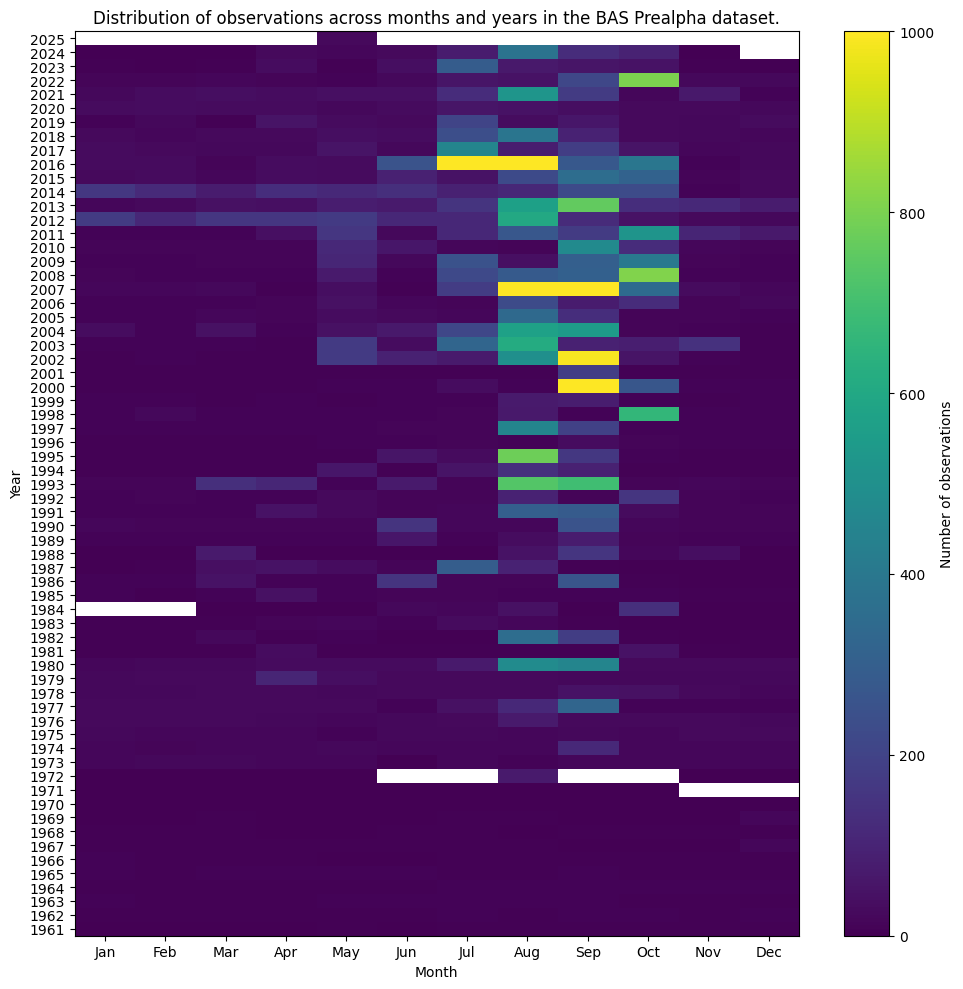

In [4]:
counts = (
    df.assign(year=df["datetime"].dt.year,
              month=df["datetime"].dt.month)
      .groupby(["year", "month"])
      .size()
      .unstack(fill_value=np.nan)
)

plt.figure(figsize=(10, 10))
plt.imshow(counts, aspect="auto", origin="lower", vmin=0, vmax=1000)
plt.colorbar(label="Number of observations")

plt.xticks(range(12), ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"])
plt.yticks(range(len(counts.index)), counts.index)

plt.xlabel("Month")
plt.ylabel("Year")
plt.title("Distribution of observations across months and years in the BAS Prealpha dataset.")

plt.tight_layout()
plt.show()

##### Perform QC

Now, we QC for different input variables. We definitely want longitude & latitude as an input, but other options are:
* Salinity only
* Temperature only
* Pressure only
* Salinity & temperature
* Salinity & pressure

Note that "pressure" and "depth" are synonymous

In [5]:
# First, we need to QC the data depending on which variables we are using
var_dic = {"S": [salinity_field, longitude_field, latitude_field],
           "T": [temperature_field, longitude_field, latitude_field],
           "P": [depth_field, longitude_field, latitude_field],
           "ST": [salinity_field, temperature_field, longitude_field, latitude_field],
           "TP": [temperature_field, depth_field, longitude_field, latitude_field],
           "SP": [salinity_field, depth_field, longitude_field, latitude_field],
           "STP": [salinity_field, temperature_field, depth_field, longitude_field, latitude_field]
}

df_qc_dic = {"S": df.dropna(subset=[*var_dic["S"], oxygen_iso_field]),
             "T": df.dropna(subset=[*var_dic["T"], oxygen_iso_field]),
             "P": df.dropna(subset=[*var_dic["P"], oxygen_iso_field]),
              "ST": df.dropna(subset=[*var_dic["ST"], oxygen_iso_field]),
              "TP": df.dropna(subset=[*var_dic["TP"], oxygen_iso_field]),
              "SP": df.dropna(subset=[*var_dic["SP"], oxygen_iso_field]),
              "STP": df.dropna(subset=[*var_dic["STP"], oxygen_iso_field])
}

In [6]:
print(f"Pre-QC, there are {len(df)} data points.")
for key, val in df_qc_dic.items():
    print(f"The percentage of data lost for {key} QC is {np.round((len(df) - len(val))/len(df)*100, 2)}%")

Pre-QC, there are 52053 data points.
The percentage of data lost for S QC is 27.25%
The percentage of data lost for T QC is 29.15%
The percentage of data lost for P QC is 28.65%
The percentage of data lost for ST QC is 30.7%
The percentage of data lost for TP QC is 32.07%
The percentage of data lost for SP QC is 29.75%
The percentage of data lost for STP QC is 33.13%


#### A.2 Train a model on the pre-alpha database that can predict delta18O from salinity, temperature and pressure.

In [7]:
df_qcd = df_qc_dic["STP"]

In [8]:
# Create the 90% for training & 10% for inference
df_10 = df_qcd.sample(frac=0.10)  # 10% sample
df_90 = df_qcd.drop(df_10.index)  # get rest

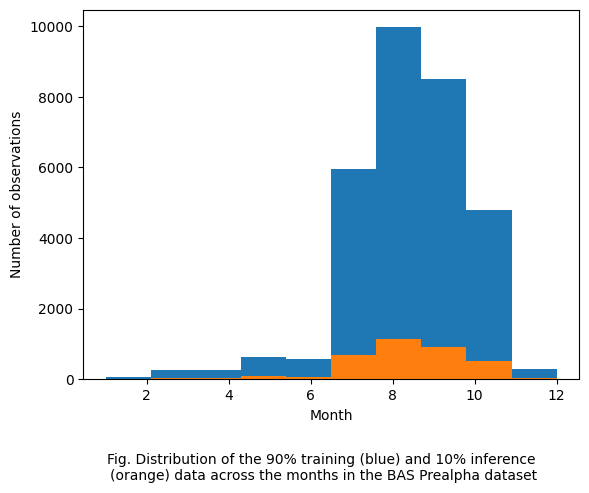

In [9]:
# Add a plot of distribution across the months for 90% & 10% as a check
fig, ax = plt.subplots()

ax.hist(df_90['datetime'].dt.month)
ax.hist(df_10['datetime'].dt.month)

ax.set_xlabel("Month")
ax.set_ylabel("Number of observations")

caption = "Fig. Distribution of the 90% training (blue) and 10% inference \n(orange) data across the months in the BAS Prealpha dataset"
tx = fig.text(0.5, -0.1, caption, ha="center", fontsize=10)

In [10]:
# Call the ML model
ml_model = ml.MLModel(df_90, df_10, [salinity_field, temperature_field, depth_field, "x", "y"], oxygen_iso_field)
# Training
trained_model = ml_model.training()
# Inference
model_test = ml_model.inference(trained_model[1], trained_model[0])

ML Predicted Oxygen RMSE: 0.3956832891180553
ML Predicted Oxygen R2: 0.9020258614333954
ML Predicted Oxygen Error Percentiles [0.00958616 0.04796004 0.11617755 0.28691703 0.8800281 ]


#### A.3 Use the model to predict delta18O abundance across the Arctic ocean using the AOR dataset.

In [11]:
#AOR data downloaded from: https://data.marine.copernicus.eu/product/ARCTIC_MULTIYEAR_PHY_002_003/files?subdataset=cmems_mod_arc_phy_my_topaz4_P1M_202506&path=ARCTIC_MULTIYEAR_PHY_002_003%2Fcmems_mod_arc_phy_my_topaz4_P1M_202506%2F2016%2F
aor = climdata("./INPUT_DATA/NERSC-MODEL-TOPAZ4B-ARC-RAN_mm-12km_20160915_20250428.fv2.0.nc") #this file is for 09-2016
sal_aor = aor.so
temp_aor = aor.thetao

In [12]:

import importlib
importlib.reload(ml)

<module 'helper_functions.ML_functions' from '/home/ezrkit/Code/github-repos/AISIT_challenge/hackathon_template_repo/helper_functions/ML_functions.py'>

In [13]:
aor_oxy_vals = []
# Select some pressure levels
depths = [2, 10, 40, 100, 200, 400]
aor_depths = aor.sel(depth=depths)

# Convert to Cartesian coordinates
aor_cart = ml_model.spherical_to_cartesian(aor_depths, "longitude", "latitude")
ds= aor_cart.sel(time="2016-09-15").drop_vars("time").drop_vars(["x", "y"])


aor_oxy_vals.append(ml_model.apply_model(ds, ["so", "thetao"], trained_model[0], trained_model[1], x="x", y="y", z="depth").values)

FrozenMappingWarningOnValuesAccess({'y': 881, 'x': 609, 'depth': 6})
(6, 881, 609)
(3219174,)


ValueError: conflicting sizes for dimension 'depth': length 609 on the data but length 6 on coordinate 'depth'

In [ ]:

ds = aor_cart.sel(time="2016-09-15").drop_vars("time")

print("so:", ds["so"].shape)
print("thetao:", ds["thetao"].shape)
print("coords dims:", ds.dims)


so: (6, 881, 609)
thetao: (6, 881, 609)
coords dims: FrozenMappingWarningOnValuesAccess({'y': 881, 'x': 609, 'depth': 6, 'latitude': 881, 'longitude': 609})


In [ ]:

print("X coords:", ds["x"].shape)
print("Y coords:", ds["y"].shape)
print("latitude:", ds["latitude"].shape)
print("longitude:", ds["longitude"].shape)


X coords: (881, 609)
Y coords: (881, 609)
latitude: (881, 609)
longitude: (881, 609)


In [ ]:
aor_cart.sel(time="2016-09-15")

<xarray.Dataset> Size: 84MB
Dimensions:        (y: 881, x: 609, depth: 6, latitude: 881, longitude: 609)
Coordinates:
    time           datetime64[ns] 8B 2016-09-15
  * depth          (depth) float32 24B 2.0 10.0 40.0 100.0 200.0 400.0
    latitude       (y, x) float32 2MB 34.69 34.74 34.79 ... 34.79 34.74 34.69
    longitude      (y, x) float32 2MB -79.64 -79.55 -79.46 ... 100.5 100.4 100.4
    x              (latitude, longitude) float32 2MB 9.42e+05 ... -9.42e+05
    y              (latitude, longitude) float32 2MB -5.153e+06 ... 5.153e+06
Data variables: (12/16)
    bottomT        (y, x) float32 2MB ...
    mlotst         (y, x) float32 2MB ...
    model_depth    (y, x) float32 2MB ...
    siconc         (y, x) float32 2MB ...
    sisnthick      (y, x) float32 2MB ...
    sithick        (y, x) float32 2MB ...
    ...             ...
    vxo            (depth, y, x) float32 13MB ...
    vxsi           (y, x) float32 2MB ...
    vyo            (depth, y, x) float32 13MB ...
    vysi           (y, x) float32 2MB ...
    zos            (y, x) float32 2MB ...
    sithick_corr   (y, x) float32 2MB ...
Attributes:
    institution:  NERSC, Jahnebakken 3, N-5007 Bergen, Norway
    source:       NERSC-HYCOM model fields
    references:   https://doi.org/10.48670/moi-00007
    field_type:   Files based on file type nersc_weekly
    Conventions:  CF-1.4
    field_date:   2016-09-15
    title:        Arctic Ocean Physics Reanalysis, 12.5km monthly mean

In [ ]:
aor_cart.drop_vars("time").drop_vars(["x", "y"]),

(<xarray.Dataset> Size: 79MB
 Dimensions:        (time: 1, y: 881, x: 609, depth: 6)
 Coordinates:
   * depth          (depth) float32 24B 2.0 10.0 40.0 100.0 200.0 400.0
     latitude       (y, x) float32 2MB 34.69 34.74 34.79 ... 34.79 34.74 34.69
     longitude      (y, x) float32 2MB -79.64 -79.55 -79.46 ... 100.5 100.4 100.4
 Dimensions without coordinates: time, y, x
 Data variables: (12/16)
     bottomT        (time, y, x) float32 2MB ...
     mlotst         (time, y, x) float32 2MB ...
     model_depth    (y, x) float32 2MB ...
     siconc         (time, y, x) float32 2MB ...
     sisnthick      (time, y, x) float32 2MB ...
     sithick        (time, y, x) float32 2MB ...
     ...             ...
     vxo            (time, depth, y, x) float32 13MB ...
     vxsi           (time, y, x) float32 2MB ...
     vyo            (time, depth, y, x) float32 13MB ...
     vysi           (time, y, x) float32 2MB ...
     zos            (time, y, x) float32 2MB ...
     sithick_corr   (time

In [ ]:

print(ds.dims)
print(ds[data_vars[0]].shape)
print(mean_pred.shape)


FrozenMappingWarningOnValuesAccess({'y': 881, 'x': 609, 'depth': 6, 'latitude': 881, 'longitude': 609})
(6, 881, 609)


NameError: name 'mean_pred' is not defined

In [ ]:
aor_cart

<xarray.Dataset> Size: 84MB
Dimensions:        (time: 1, y: 881, x: 609, depth: 6, latitude: 881,
                    longitude: 609)
Coordinates:
  * time           (time) datetime64[ns] 8B 2016-09-15
  * depth          (depth) float32 24B 2.0 10.0 40.0 100.0 200.0 400.0
    latitude       (y, x) float32 2MB 34.69 34.74 34.79 ... 34.79 34.74 34.69
    longitude      (y, x) float32 2MB -79.64 -79.55 -79.46 ... 100.5 100.4 100.4
    x              (latitude, longitude) float32 2MB 9.42e+05 ... -9.42e+05
    y              (latitude, longitude) float32 2MB -5.153e+06 ... 5.153e+06
Data variables: (12/16)
    bottomT        (time, y, x) float32 2MB ...
    mlotst         (time, y, x) float32 2MB ...
    model_depth    (y, x) float32 2MB ...
    siconc         (time, y, x) float32 2MB ...
    sisnthick      (time, y, x) float32 2MB ...
    sithick        (time, y, x) float32 2MB ...
    ...             ...
    vxo            (time, depth, y, x) float32 13MB ...
    vxsi           (time, y, x) float32 2MB ...
    vyo            (time, depth, y, x) float32 13MB ...
    vysi           (time, y, x) float32 2MB ...
    zos            (time, y, x) float32 2MB ...
    sithick_corr   (time, y, x) float32 2MB ...
Attributes:
    institution:  NERSC, Jahnebakken 3, N-5007 Bergen, Norway
    source:       NERSC-HYCOM model fields
    references:   https://doi.org/10.48670/moi-00007
    field_type:   Files based on file type nersc_weekly
    Conventions:  CF-1.4
    field_date:   2016-09-15
    title:        Arctic Ocean Physics Reanalysis, 12.5km monthly mean

### Challenge B: Evaluation of gridded dataset performance against training data (SCORED OUT OF 33). 

In [ ]:
#Insert Challenge B Code Here (make more cells if needed)

Insert Challenge B markdown here (make more cells if needed)

### Challenge C: Statistical and scientific inference using your grid (SCORED OUT OF 33). 

In [ ]:
# Insert Challenge C Code Here (make more cells if needed)

Insert Challenge C markdown here (make more cells if needed)